In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/vinuni_datathon2026/raw_datasets/inventory.csv'
df = pd.read_csv(file_path)

# Hiển thị 5 dòng đầu tiên
display(df.head())

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


# **Data Dictionary**

| Column Name        | Data Type | Description |
|--------------------|----------|-------------|
| snapshot_date      | date     | Ngày chụp ảnh tồn kho (cuối tháng) |
| product_id         | int      | Khóa ngoại (FK) liên kết tới bảng products.product_id |
| stock_on_hand      | int      | Số lượng tồn kho cuối tháng |
| units_received     | int      | Số lượng nhập kho trong tháng |
| units_sold         | int      | Số lượng bán ra trong tháng |
| stockout_days      | int      | Số ngày hết hàng trong tháng |
| days_of_supply     | float    | Số ngày tồn kho có thể đáp ứng nhu cầu bán |
| fill_rate          | float    | Tỷ lệ đơn hàng được đáp ứng đầy đủ từ tồn kho |
| stockout_flag      | int      | Cờ báo tháng có xảy ra hết hàng (1 = Có, 0 = Không) |
| overstock_flag     | int      | Cờ báo tồn kho vượt mức cần thiết (1 = Có, 0 = Không) |
| reorder_flag       | int      | Cờ báo cần tái đặt hàng sớm (1 = Có, 0 = Không) |
| sell_through_rate  | float    | Tỷ lệ hàng đã bán so với tổng hàng sẵn có |
| product_name       | str      | Tên sản phẩm |
| category           | str      | Danh mục sản phẩm |
| segment            | str      | Phân khúc sản phẩm |
| year               | int      | Năm trích từ snapshot_date |
| month              | int      | Tháng trích từ snapshot_date |

# **Dataset Overview & Data Quality Checks**

### **1. Dataset Overview**

In [ ]:
print('--- Dataset Info ---')
df.info()

print('\n--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Duplicate Rows ---')
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

print('\n--- Statistical Summary ---')
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   snapshot_date      60247 non-null  object 
 1   product_id         60247 non-null  int64  
 2   stock_on_hand      60247 non-null  int64  
 3   units_received     60247 non-null  int64  
 4   units_sold         60247 non-null  int64  
 5   stockout_days      60247 non-null  int64  
 6   days_of_supply     60247 non-null  float64
 7   fill_rate          60247 non-null  float64
 8   stockout_flag      60247 non-null  int64  
 9   overstock_flag     60247 non-null  int64  
 10  reorder_flag       60247 non-null  int64  
 11  sell_through_rate  60247 non-null  float64
 12  product_name       60247 non-null  object 
 13  category           60247 non-null  object 
 14  segment            60247 non-null  object 
 15  year               60247 non-null  int64  
 16  m

,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
std,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629
min,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000


**Nhận xét:**
- Thông tin chung: Tập dữ liệu có 60,247 dòng và 17 cột. Hầu hết các cột là dạng số (int64, float64), ngoại trừ `snapshot_date`, `product_name`, `category`, và `segment` là dạng object.
- Không có missing values.
- Phân phối dữ liệu bị lệch mạnh:
  + `units_sold`: trung bình bán được khoảng 15 đơn vị mỗi tháng, nhưng có sản phẩm bán tới 670 đơn vị.
  + `stock_on_hand`: median = 62 nhưng max = 2673
  + `days_of_supply`: median = 240 nhưng max = 68100
  + CÓ KHẢ NĂNG CÓ OUTLIERS RẤT LỚN, CÁCH TÍNH `days_of_supply` có thể có vấn đề.
- Dấu hiệu tồn kho dư thừa (overstock):
  + `stock_on_hand` trung bình (189) >>` units_sold` trung bình (15).
  + `sell_through_rate` trung bình chỉ 0.15.
  + RẤT NHIỀU MẶT HÀNG BỊ GIAM VỐN.
- Tỷ lệ hết hàng (stockout) cao bất thường:
  + `stockout_flag`: giá trị trung bình là 0.67, cho thấy có khá nhiều trường hợp hết hàng trong tháng.
  + `stockout_days` trung bình ~1.16 ngày/tháng\
  + VỪA OVERSTOCK VỪA STOCKOUT NHIỀU. CÓ THỂ PHÂN BỔ TỒN KHO KÉM.
- Fill rate cao nhưng vẫn stockout:
  + `fill_rate` ~ 0.96 (rất cao)
  + ĐA SỐ ĐƠN HÀNG VẪN ĐƯỢC ĐÁP ỨNG NHƯNG CÓ STOCKOUT NGẮN HẠN.
- Cột `reorder_flag` = 0 toàn bộ.
- Hệ thống đang giữ tồn kho quá nhiềU VÌ `overstock` ~ 0.76.
- Dữ liệu thời gian ổn.

**ĐỀ XUẤT BƯỚC TIẾP THEO:**
- Chuyển `product_id` sang dạng object cho dễ phân tích.
- Chuyển các cột thời gian sang datetime.
- Check Numerical data:
  + Kiểm tra outliers và tính toán lại `days_of_supply`.
  + Xem phân phối dữ liệu của các biến số.
  + Kiểm tra `snapshot_day`, `year`, `month` hợp lệ.
- Check Catgorical data:
  + Kiểm tra các biến object có những danh mục nào, id có gì bất thường không.

## **2. Data Quality Check**

In [ ]:
df_copy = df.copy()

In [ ]:
# Chuyển product_id sang object
df_copy['product_id'] = df_copy['product_id'].astype(str)

# Chuyển snapshot_date sang datetime
df_copy['snapshot_date'] = pd.to_datetime(df_copy['snapshot_date'])

# Kiểm tra lại kiểu dữ liệu
print(df_copy[['product_id', 'snapshot_date']].dtypes)

product_id               object
snapshot_date    datetime64[ns]
dtype: object


In [ ]:
# Kiểm tra tính nhất quán giữa snapshot_date và cột year, month
df_copy['extracted_year'] = df_copy['snapshot_date'].dt.year
df_copy['extracted_month'] = df_copy['snapshot_date'].dt.month

# So sánh
year_check = (df_copy['year'] == df_copy['extracted_year']).all()
month_check = (df_copy['month'] == df_copy['extracted_month']).all()

print(f"Cột 'year' khớp hoàn toàn: {year_check}")
print(f"Cột 'month' khớp hoàn toàn: {month_check}")

# Hiển thị các dòng không khớp nếu có
if not year_check or not month_check:
    mismatched = df_copy[(df_copy['year'] != df_copy['extracted_year']) | (df_copy['month'] != df_copy['extracted_month'])]
    print(f"Số lượng dòng không khớp: {len(mismatched)}")
    display(mismatched[['snapshot_date', 'year', 'month', 'extracted_year', 'extracted_month']].head())

# Xóa các cột phụ sau khi kiểm tra
df_copy.drop(columns=['extracted_year', 'extracted_month'], inplace=True)

Cột 'year' khớp hoàn toàn: True
Cột 'month' khớp hoàn toàn: True


### **NUMERICAL DATA**

Tỷ lệ khớp logic days_of_supply: 100.00%


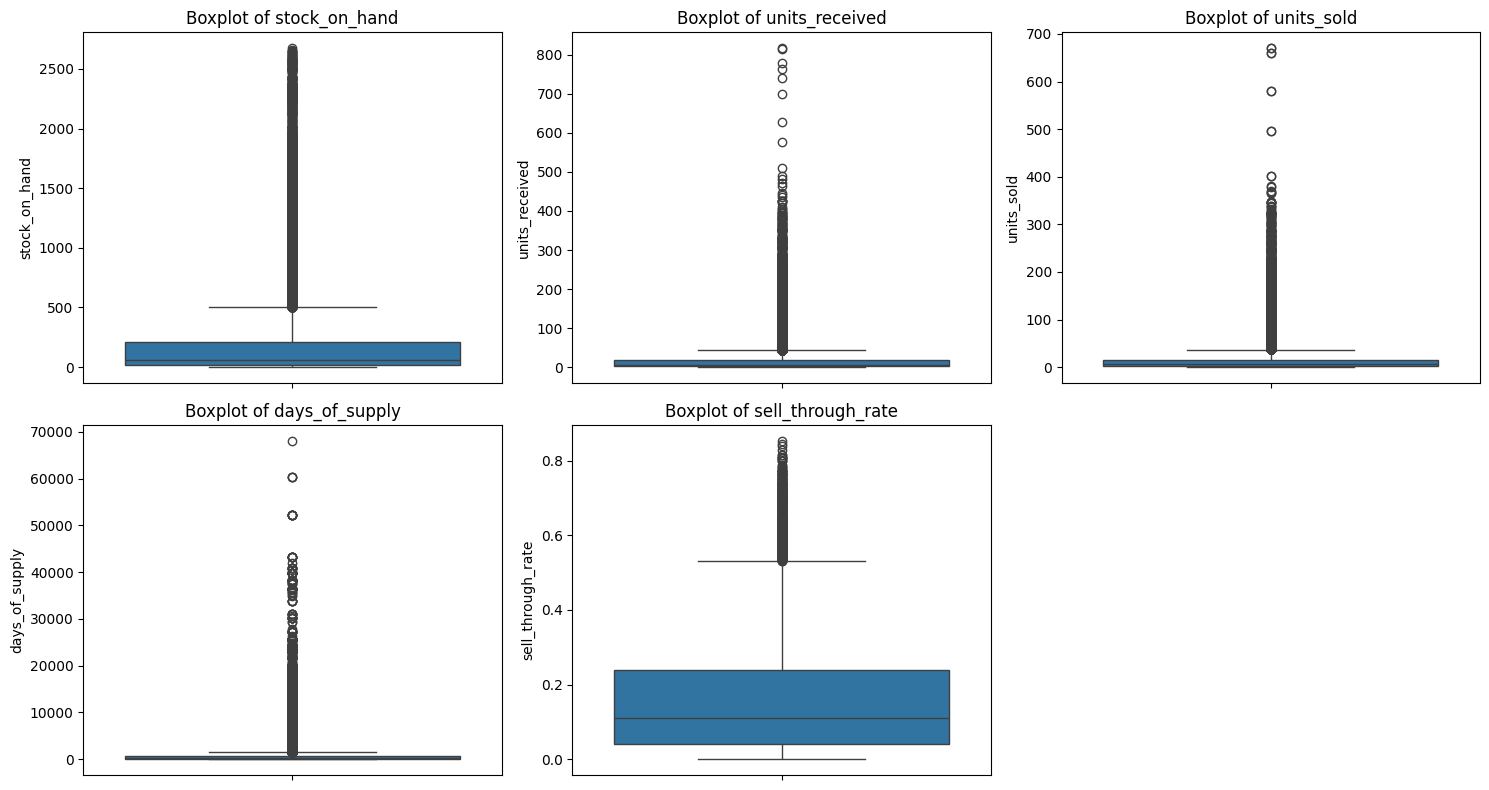

In [ ]:
# 1. Kiểm tra logic days_of_supply
# Giả định: days_of_supply = stock_on_hand / (units_sold / 30)
df_copy['calc_days_of_supply'] = (df_copy['stock_on_hand'] / (df_copy['units_sold'] / 30)).replace([np.inf, -np.inf], 0)

# Kiểm tra khớp
df_copy['is_match'] = np.isclose(
    df_copy['days_of_supply'],
    df_copy['calc_days_of_supply'],
    atol=0.1
)

match_rate = df_copy['is_match'].mean() * 100
print(f"Tỷ lệ khớp logic days_of_supply: {match_rate:.2f}%")

# Xóa ngay các cột phụ sau khi check
df_copy.drop(columns=['calc_days_of_supply', 'is_match'], inplace=True)

# 2. Kiểm tra Outliers bằng Boxplot
numerical_cols = ['stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'sell_through_rate']
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_copy[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

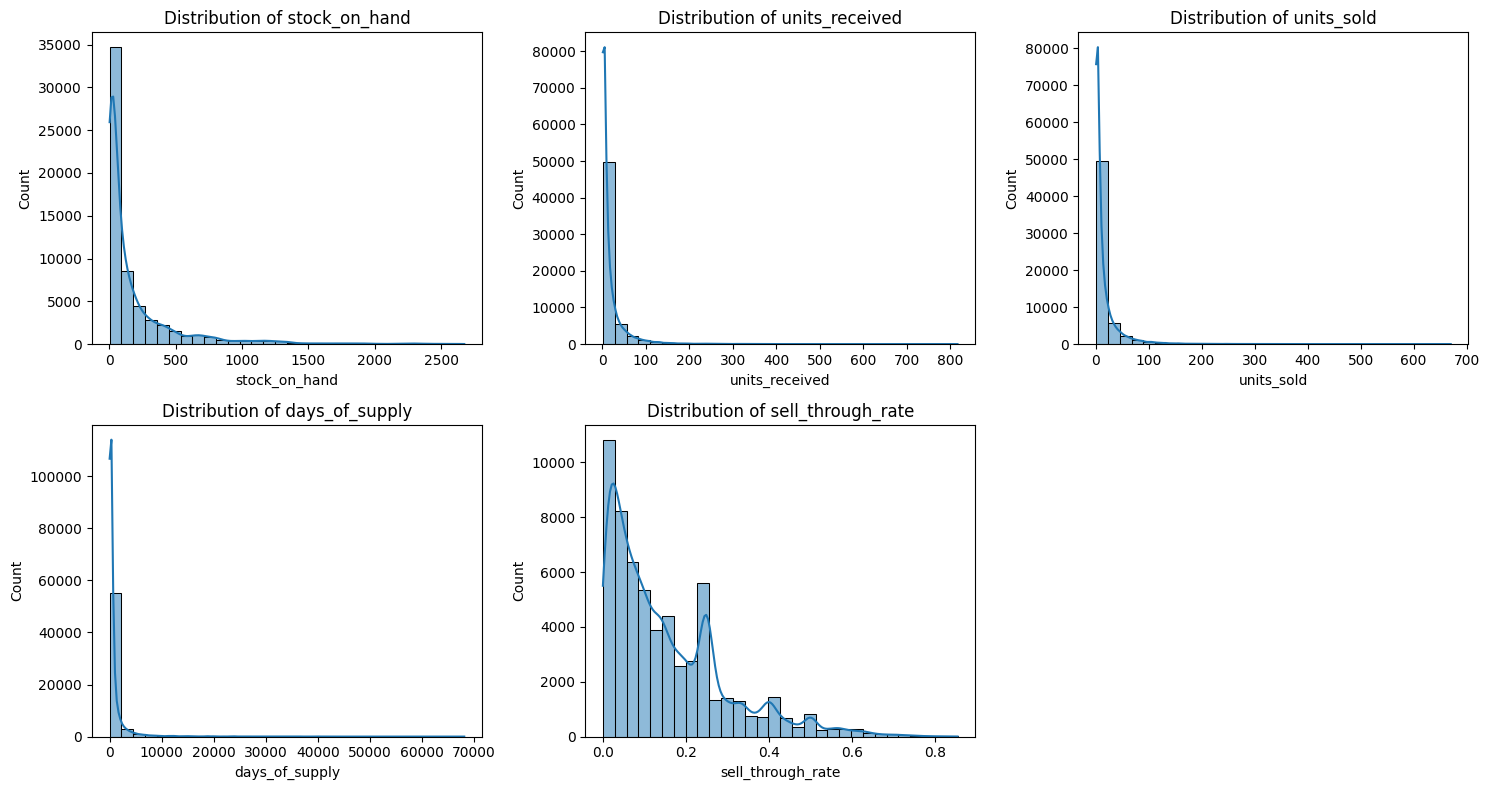

In [ ]:
# 3. Xem phân phối (Histogram) để thấy độ lệch (Skewness)
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_copy[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Nhận xét các outliers:**
- **Days of Supply (Ngoại lệ cực lớn)**: Đây là cột có vấn đề nhất. Trong khi phần lớn dữ liệu nằm ở mức thấp, có những giá trị lên tới hơn 60,000 ngày. Điều này thường xảy ra khi units_sold rất nhỏ nhưng vẫn có hàng tồn kho, dẫn đến phép tính bị phóng đại quá mức.
- **Stock on Hand & Units Received/Sold:** Cả ba cột này đều bị lệch phải (Right-skewed) rất mạnh. Hầu hết các sản phẩm có lượng tồn kho và doanh số thấp, nhưng có một số ít 'siêu sản phẩm' có số lượng cực lớn (outliers).
- **Sell Through Rate:** Tỷ lệ này tập trung chủ yếu ở mức thấp (dưới 0.2), cho thấy tốc độ đẩy hàng đang khá chậm so với lượng hàng tồn.
- **Sự mâu thuẫn:** Dữ liệu vừa có nhiều outliers về tồn kho lớn (overstock), vừa có tỷ lệ stockout cao (theo thống kê trước đó). Điều này khẳng định giả thuyết về việc phân bổ hàng hóa không đồng đều giữa các nhóm sản phẩm. Ví dụ có 100 sản phẩm: 70 sản phẩm không ai mua nhưng được nhập về rất nhiều. 30 sản phẩm bán chạy nhưng lại không nhập đủ hàng.

**Kiểm tra các biến nhị phân (Flags)**

Xem xét tỷ lệ xuất hiện của các cờ báo hiệu (1 = Có, 0 = Không) để đánh giá tình trạng vận hành.

Tỷ lệ stockout_flag:
stockout_flag
1    67.341112
0    32.658888

Tỷ lệ overstock_flag:
overstock_flag
1    76.256079
0    23.743921

Tỷ lệ reorder_flag:
reorder_flag
0    100.0



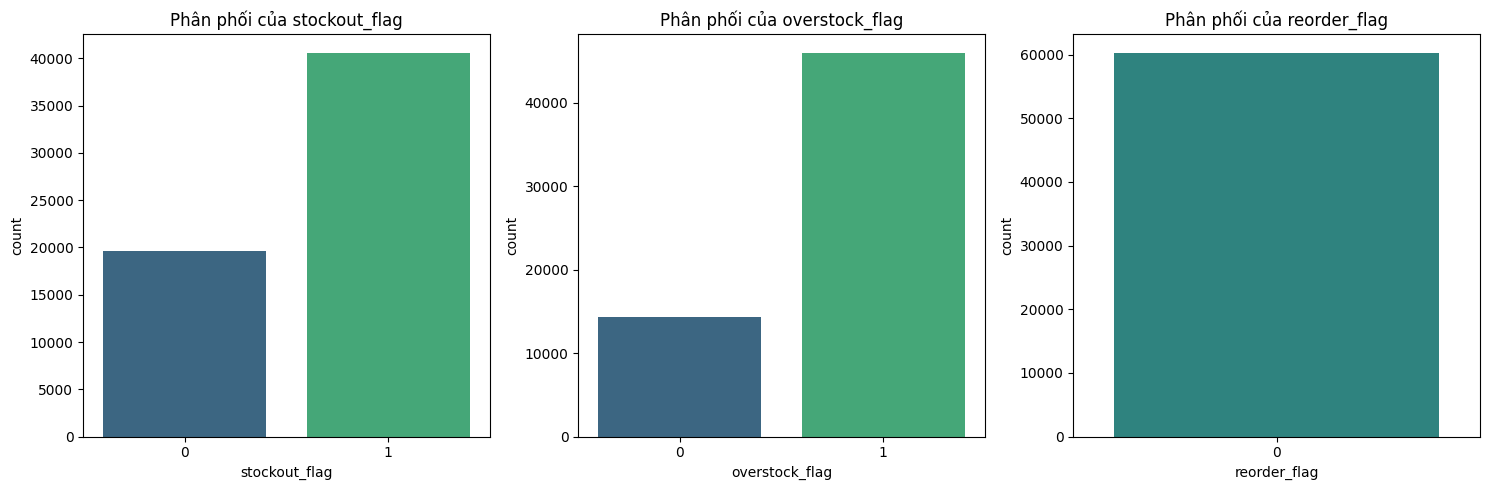

In [ ]:
binary_cols = ['stockout_flag', 'overstock_flag', 'reorder_flag']

plt.figure(figsize=(15, 5))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=col, data=df_copy, palette='viridis')
    plt.title(f'Phân phối của {col}')

    # Tính tỷ lệ phần trăm
    counts = df_copy[col].value_counts(normalize=True) * 100
    print(f"Tỷ lệ {col}:\n{counts.to_string()}\n")

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Tỷ lệ Stockout rất cao (67.34%):** Hơn 2/3 số mặt hàng gặp tình trạng hết hàng tại một thời điểm nào đó trong tháng. Đây là dấu hiệu của việc thiếu hụt hàng hóa nghiêm trọng hoặc dự báo nhu cầu chưa sát.
- **Tỷ lệ Overstock cực kỳ cao (76.26%):** Nghĩa là có tới 3/4 mặt hàng đang rơi vào tình trạng tồn kho quá mức cần thiết.
- **Nghịch lý vận hành:** Việc tỷ lệ Stockout và Overstock đều ở mức rất cao cho thấy **hệ thống đang gặp vấn đề lớn về phân bổ (Allocation).** Bạn đang giữ quá nhiều những thứ không bán được và lại thiếu những thứ khách hàng cần.
- **Cột Reorder_flag vô dụng (100% là 0)**: Cột này hiện không cung cấp thông tin vì không có bản ghi nào kích hoạt cờ tái đặt hàng. Cân nhắc loại bỏ hoặc tính toán lại logic cho cột này sau.

In [ ]:
# 4. Kiểm tra dải thời gian snapshot_date
print(f"Ngày bắt đầu: {df_copy['snapshot_date'].min()}")
print(f"Ngày kết thúc: {df_copy['snapshot_date'].max()}")
print(f"Số lượng tháng duy nhất: {df_copy['snapshot_date'].nunique()}")

# Kiểm tra xem có ngày nào không phải cuối tháng không
is_month_end = df_copy['snapshot_date'].dt.is_month_end.all()
print(f"Tất cả snapshot_date đều là cuối tháng: {is_month_end}")

Ngày bắt đầu: 2012-07-31 00:00:00
Ngày kết thúc: 2022-12-31 00:00:00
Số lượng tháng duy nhất: 126
Tất cả snapshot_date đều là cuối tháng: True


**Nhận xét về thời gian:**
- **Dải thời gian rộng:** Dữ liệu trải dài từ tháng 7/2012 đến tháng 12/2022, tổng cộng **126 tháng** (hơn 10 năm). Đây là khoảng thời gian đủ dài để thực hiện các phân tích về tính chu kỳ và xu hướng.
- **Tính nhất quán:** Tất cả các ngày snapshot đều là ngày cuối tháng, thuận lợi cho việc tổng hợp dữ liệu định kỳ.

### **CATEGORICAL DATA**

In [ ]:
# 1. Kiểm tra số lượng giá trị duy nhất
cat_cols = ['product_id', 'product_name', 'category', 'segment']

print('--- Unique Value Counts ---')
for col in cat_cols:
    print(f'{col}: {df_copy[col].nunique()}')

# 2. Liệt kê category & segment (sắp xếp cho dễ đọc)
print('\n--- Category List ---')
print(sorted(df_copy['category'].dropna().unique()))

print('\n--- Segment List ---')
print(sorted(df_copy['segment'].dropna().unique()))

# 3. Kiểm tra mapping product_id ↔ product_name
print('\n--- Consistency Check: product_id vs product_name ---')

id_name_check = df_copy.groupby('product_id')['product_name'].nunique()

inconsistent_ids = id_name_check[id_name_check > 1]

if not inconsistent_ids.empty:
    print(f'[WARNING] {len(inconsistent_ids)} product_id có nhiều hơn 1 product_name')
    display(inconsistent_ids.head())
else:
    print('OK: Mỗi product_id chỉ tương ứng với 1 product_name')

--- Unique Value Counts ---
product_id: 1624
product_name: 1465
category: 4
segment: 8

--- Category List ---
['Casual', 'GenZ', 'Outdoor', 'Streetwear']

--- Segment List ---
['Activewear', 'All-weather', 'Balanced', 'Everyday', 'Performance', 'Premium', 'Standard', 'Trendy']

--- Consistency Check: product_id vs product_name ---
OK: Mỗi product_id chỉ tương ứng với 1 product_name



## **TỔNG KẾT GIAI ĐOẠN DATA QUALITY CHECK & ĐỀ XUẤT PHÂN TÍCH:**

1. **Độ tin cậy của dữ liệu:**
    - **Dữ liệu sạch:** 60,247 dòng, không có giá trị thiếu (missing values) và không có dòng trùng lặp (duplicates).
    - **Logic thời gian:** Chính xác 100%. Dữ liệu trải dài 126 tháng (10 năm), tất cả snapshot đều là ngày cuối tháng, khớp hoàn toàn với các cột Year/Month.
    - **Định danh:** 1,624 sản phẩm được mapping nhất quán 1:1 giữa `product_id` và `product_name`.

2. **Các phát hiện quan trọng (Insights):**
    - **Nghịch lý vận hành:** Hệ thống đang gặp lỗi phân bổ (Allocation) nghiêm trọng khi **vừa Overstock (76%) vừa Stockout (67%)**. Điều này cho thấy hàng hóa không được đưa đến đúng nơi cần thiết.
    - **Vấn đề Outliers:** Cột `days_of_supply` bị nhiễu nặng bởi các giá trị phi lý (lên tới 45-50 năm) do doanh số quá thấp. Cần xử lý bằng phương pháp Capping (chặn trần 365 ngày).
    - **Đặc tính danh mục:** Hệ thống phân loại gồm 4 Categories và 8 Segments rất rõ ràng, thuận lợi cho việc phân tích nhóm.

3. **Đề xuất các chỉ số bổ sung cho giai đoạn EDA chuyên sâu:**
    - **Inventory Turnover Ratio (Hệ số quay vòng hàng tồn kho):** Tính toán theo năm để đánh giá hiệu quả sử dụng vốn của từng nhóm hàng.
    - **GMROI (Gross Margin Return on Investment):** (Nếu có dữ liệu giá) để xem nhóm hàng nào mang lại lợi nhuận thực sự trên mỗi đồng vốn tồn kho.
    - **Phân loại ABC/XYZ:** Để xếp hạng mức độ quan trọng và tính ổn định của sản phẩm.

*LƯU Ý QUAN TRỌNG: Outliers cực lớn ở cột `days_of_supply`**

Trong quá trình kiểm tra dữ liệu, chúng ta phát hiện cột `days_of_supply` có những giá trị lên tới hàng chục nghìn ngày (ví dụ: 16,680 ngày ~ 45 năm).

**Nguyên nhân:**
- Công thức tính là: `stock_on_hand / (units_sold / 30)`.
- Khi một sản phẩm có tồn kho (`stock_on_hand`) nhưng lượng bán ra trong tháng cực thấp (ví dụ `units_sold` = 1 hoặc 2), mẫu số của phép chia sẽ rất nhỏ, khiến kết quả cuối cùng bị đẩy lên mức phi lý.

**Hệ quả:**
- Những giá trị ngoại lai (outliers) này sẽ làm sai lệch hoàn toàn các phép tính thống kê như **Số trung bình (Mean)**.
- Ví dụ: Một sản phẩm tồn kho 50 năm sẽ kéo trung bình của cả nhóm lên cao, làm ta lầm tưởng là toàn bộ kho hàng đều đang bị ứ đọng, dù thực tế 90% các mã hàng khác có thể đang sắp hết hàng.

**Hướng xử lý đề xuất:**
- Cần thiết lập giới hạn trần (Capping/Clipping), ví dụ tối đa là 365 ngày (1 năm).
- Mọi giá trị lớn hơn 365 sẽ được đưa về 365 để phản ánh đúng bản chất là "Hàng tồn kho chậm" mà không làm hỏng các hàm tính toán sau này.

In [ ]:
# Lưu file vào thư mục trên Google Drive
drive_output_path = '/content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/inventory_cleaned.csv'
df_copy.to_csv(drive_output_path, index=False)

print(f"Đã lưu file vào Drive thành công: {drive_output_path}")

Đã lưu file vào Drive thành công: /content/drive/MyDrive/vinuni_datathon2026/cleaned_datasets/inventory_cleaned.csv
